# Heat Exchanger Network Match Selection as QUBO/QAOA

A heat exchange network is a viable quantum-optimization direction, with one important caveat: **do not claim the whole thermodynamic design problem is solved by a quantum circuit**.

The full Heat Exchanger Network Synthesis problem includes continuous heat duties, stream temperatures, exchanger area, pressure drops, non-isothermal mixing, utilities, and practical plant constraints. That is typically formulated as a difficult MINLP or a hybrid global/local optimization problem.

The quantum-friendly injection point is narrower and more credible:

> Use a quantum optimizer for the **binary topology layer**: which hot-cold stream matches should exist, which retrofit connections should be opened, or which candidate exchangers/utilities should be selected. Then pass that topology to a classical NLP/MINLP solver for heat balances and exchanger sizing.

This notebook implements a small proof-of-concept: candidate hot-cold stream matches are converted into a QUBO, then solved exactly, by simulated annealing, and by a tiny statevector QAOA-style optimizer.

## 1. Imports

The QAOA implementation below is intentionally explicit and small. It avoids relying on optional optimization packages that may not be installed.

In [1]:
import itertools
from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import differential_evolution

SEED = 8398
rng = np.random.default_rng(SEED)

## 2. Toy Heat Exchanger Network Data

This is not a full plant model. It is a compact candidate-match selection problem.

Each hot stream has heat it can release; each cold stream has heat it needs. A candidate match has an approximate recoverable heat and a capital cost. The optimizer selects a subset of matches that:

- recovers enough heat,
- avoids isolated streams,
- avoids selecting too many unnecessary exchangers,
- balances heat recovery benefit against capital cost.

In [2]:
@dataclass(frozen=True)
class HotStream:
    name: str
    supply_c: float
    target_c: float
    heat_capacity_kw_per_c: float

    @property
    def duty_kw(self):
        return self.heat_capacity_kw_per_c * (self.supply_c - self.target_c)


@dataclass(frozen=True)
class ColdStream:
    name: str
    supply_c: float
    target_c: float
    heat_capacity_kw_per_c: float

    @property
    def demand_kw(self):
        return self.heat_capacity_kw_per_c * (self.target_c - self.supply_c)


hot_streams = [
    HotStream("H1", supply_c=220, target_c=90, heat_capacity_kw_per_c=2.4),
    HotStream("H2", supply_c=180, target_c=70, heat_capacity_kw_per_c=1.8),
    HotStream("H3", supply_c=150, target_c=60, heat_capacity_kw_per_c=2.1),
]

cold_streams = [
    ColdStream("C1", supply_c=40, target_c=160, heat_capacity_kw_per_c=1.9),
    ColdStream("C2", supply_c=60, target_c=140, heat_capacity_kw_per_c=2.0),
    ColdStream("C3", supply_c=80, target_c=130, heat_capacity_kw_per_c=2.2),
    ColdStream("C4", supply_c=30, target_c=110, heat_capacity_kw_per_c=1.5),
]

MIN_APPROACH_C = 10
FIXED_UNIT_COST = 45.0
AREA_COST_SCALE = 0.18
UTILITY_VALUE_PER_KW = 1.0

candidates = []
for h_idx, h in enumerate(hot_streams):
    for c_idx, c in enumerate(cold_streams):
        feasible_temperature = h.supply_c >= c.target_c + MIN_APPROACH_C
        if not feasible_temperature:
            continue

        temperature_driving_force = max(5.0, h.supply_c - c.target_c)
        recoverable_kw = min(h.duty_kw, c.demand_kw) * min(1.0, temperature_driving_force / 100.0)
        capital_cost = FIXED_UNIT_COST + AREA_COST_SCALE * recoverable_kw
        utility_value = UTILITY_VALUE_PER_KW * recoverable_kw

        candidates.append({
            "hot": h.name,
            "cold": c.name,
            "hot_idx": h_idx,
            "cold_idx": c_idx,
            "recoverable_kw": recoverable_kw,
            "capital_cost": capital_cost,
            "net_linear_cost": capital_cost - utility_value,
        })

print("hot duties:", {h.name: round(h.duty_kw, 1) for h in hot_streams})
print("cold demands:", {c.name: round(c.demand_kw, 1) for c in cold_streams})
print("candidate matches:")
for i, cand in enumerate(candidates):
    print(i, cand)

hot duties: {'H1': 312.0, 'H2': 198.0, 'H3': 189.0}
cold demands: {'C1': 228.0, 'C2': 160.0, 'C3': 110.0, 'C4': 120.0}
candidate matches:
0 {'hot': 'H1', 'cold': 'C1', 'hot_idx': 0, 'cold_idx': 0, 'recoverable_kw': 136.79999999999998, 'capital_cost': 69.624, 'net_linear_cost': -67.17599999999999}
1 {'hot': 'H1', 'cold': 'C2', 'hot_idx': 0, 'cold_idx': 1, 'recoverable_kw': 128.0, 'capital_cost': 68.03999999999999, 'net_linear_cost': -59.96000000000001}
2 {'hot': 'H1', 'cold': 'C3', 'hot_idx': 0, 'cold_idx': 2, 'recoverable_kw': 99.00000000000001, 'capital_cost': 62.82, 'net_linear_cost': -36.180000000000014}
3 {'hot': 'H1', 'cold': 'C4', 'hot_idx': 0, 'cold_idx': 3, 'recoverable_kw': 120.0, 'capital_cost': 66.6, 'net_linear_cost': -53.400000000000006}
4 {'hot': 'H2', 'cold': 'C1', 'hot_idx': 1, 'cold_idx': 0, 'recoverable_kw': 39.6, 'capital_cost': 52.128, 'net_linear_cost': 12.527999999999999}
5 {'hot': 'H2', 'cold': 'C2', 'hot_idx': 1, 'cold_idx': 1, 'recoverable_kw': 64.0, 'capital_c

## 3. QUBO Formulation

We use one binary variable per candidate match:

\[
x_i = 1 \quad 	ext{if candidate exchanger } i 	ext{ is selected.}
\]

The toy objective is:

\[
E(x) = \sum_i c_i x_i + P_R(R_	ext{target} - \sum_i r_i x_i)^2 + P_S \sum_s (1 - \sum_{i \in s} x_i)^2.
\]

Interpretation:

- `c_i` is net match cost after approximate utility benefit.
- the recovery penalty pushes the design toward a heat-recovery target.
- the stream penalty discourages leaving streams unmatched.

This is a topology-screening proxy, not a final HEN design.

In [3]:
def build_qubo(candidates, target_recovery_kw, recovery_penalty=0.012, stream_penalty=18.0):
    """Build an upper-triangular QUBO matrix Q and constant offset.

    Objective: x.T @ Q @ x + constant, where x is binary.
    """
    n = len(candidates)
    Q = np.zeros((n, n), dtype=float)
    constant = 0.0

    recovered = np.array([cand["recoverable_kw"] for cand in candidates], dtype=float)
    linear_cost = np.array([cand["net_linear_cost"] for cand in candidates], dtype=float)

    # Linear match costs.
    for i in range(n):
        Q[i, i] += linear_cost[i]

    # Recovery target penalty: P * (T - sum r_i x_i)^2.
    P = recovery_penalty
    T = target_recovery_kw
    constant += P * T**2
    for i in range(n):
        Q[i, i] += P * recovered[i] ** 2 - 2 * P * T * recovered[i]
        for j in range(i + 1, n):
            Q[i, j] += 2 * P * recovered[i] * recovered[j]

    # Stream coverage penalties: P_s * (1 - sum incident x_i)^2.
    stream_names = [h.name for h in hot_streams] + [c.name for c in cold_streams]
    for stream in stream_names:
        incident = [
            i for i, cand in enumerate(candidates)
            if cand["hot"] == stream or cand["cold"] == stream
        ]
        if not incident:
            continue
        constant += stream_penalty
        for i in incident:
            Q[i, i] += stream_penalty - 2 * stream_penalty
        for a, i in enumerate(incident):
            for j in incident[a + 1:]:
                ii, jj = sorted((i, j))
                Q[ii, jj] += 2 * stream_penalty

    return Q, constant


def qubo_energy(bits, Q, constant=0.0):
    bits = np.asarray(bits, dtype=float)
    return float(bits @ Q @ bits + constant)


def design_summary(bits, candidates):
    selected = [i for i, bit in enumerate(bits) if bit]
    recovered = sum(candidates[i]["recoverable_kw"] for i in selected)
    capital = sum(candidates[i]["capital_cost"] for i in selected)
    matches = [(candidates[i]["hot"], candidates[i]["cold"]) for i in selected]
    return {
        "n_matches": len(selected),
        "recovered_kw": recovered,
        "capital_cost_proxy": capital,
        "matches": matches,
    }

TARGET_RECOVERY_KW = 360.0
Q, constant = build_qubo(
    candidates,
    target_recovery_kw=TARGET_RECOVERY_KW,
    recovery_penalty=0.012,
    stream_penalty=18.0,
)

print("number of binary variables:", len(candidates))
print("constant offset:", constant)
print("QUBO matrix shape:", Q.shape)

number of binary variables: 11
constant offset: 1681.2
QUBO matrix shape: (11, 11)


## 4. Exact Solver for the Small Toy Problem

For this tiny problem we can enumerate all bitstrings. In a real plant, this is exactly what becomes impossible as candidate matches, stages, utilities, and operating periods grow.

In [4]:
def exact_solve_qubo(Q, constant):
    n = Q.shape[0]
    best_bits = None
    best_energy = np.inf
    all_rows = []

    for bits_tuple in itertools.product([0, 1], repeat=n):
        bits = np.array(bits_tuple, dtype=int)
        energy = qubo_energy(bits, Q, constant)
        all_rows.append((energy, bits))
        if energy < best_energy:
            best_energy = energy
            best_bits = bits.copy()

    all_rows.sort(key=lambda row: row[0])
    return best_bits, best_energy, all_rows

best_bits, best_energy, all_rows = exact_solve_qubo(Q, constant)

print("best energy:", best_energy)
print("best bits:", best_bits.tolist())
print("best design:", design_summary(best_bits, candidates))

print()
print("Top 5 designs:")
for rank, (energy, bits) in enumerate(all_rows[:5], start=1):
    print(rank, "energy=", round(energy, 3), design_summary(bits, candidates))

best energy: -104.65632000000005
best bits: [1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0]
best design: {'n_matches': 4, 'recovered_kw': 370.8, 'capital_cost_proxy': 246.74399999999997, 'matches': [('H1', 'C1'), ('H1', 'C2'), ('H2', 'C4'), ('H3', 'C3')]}

Top 5 designs:
1 energy= -104.656 {'n_matches': 4, 'recovered_kw': 370.8, 'capital_cost_proxy': 246.74399999999997, 'matches': [('H1', 'C1'), ('H1', 'C2'), ('H2', 'C4'), ('H3', 'C3')]}
2 energy= -102.866 {'n_matches': 4, 'recovered_kw': 367.8, 'capital_cost_proxy': 246.20399999999998, 'matches': [('H1', 'C1'), ('H1', 'C2'), ('H2', 'C3'), ('H3', 'C4')]}
3 energy= -95.511 {'n_matches': 3, 'recovered_kw': 348.79999999999995, 'capital_cost_proxy': 197.784, 'matches': [('H1', 'C1'), ('H1', 'C2'), ('H2', 'C4')]}
4 energy= -85.41 {'n_matches': 4, 'recovered_kw': 347.8, 'capital_cost_proxy': 242.60399999999998, 'matches': [('H1', 'C1'), ('H1', 'C3'), ('H2', 'C2'), ('H3', 'C4')]}
5 energy= -79.546 {'n_matches': 4, 'recovered_kw': 342.8, 'capital_cost_proxy

## 5. Classical Simulated Annealing Baseline

Quantum optimization should be compared against cheap classical heuristics. This simple simulated annealer flips one match variable at a time.

SA energy: -79.54592000000025
SA bits: [1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0]
SA design: {'n_matches': 4, 'recovered_kw': 342.8, 'capital_cost_proxy': 241.70399999999998, 'matches': [('H1', 'C1'), ('H1', 'C4'), ('H2', 'C2'), ('H3', 'C3')]}


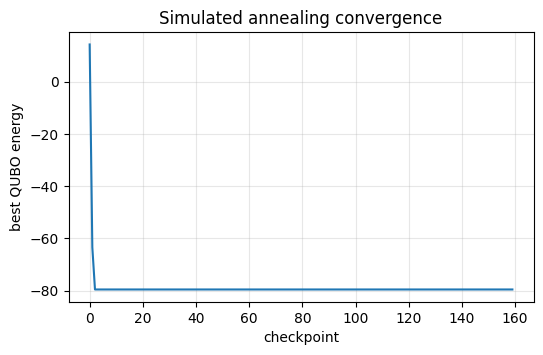

In [5]:
def simulated_annealing(Q, constant, steps=4000, start_temp=20.0, end_temp=0.05, seed=SEED):
    rng = np.random.default_rng(seed)
    n = Q.shape[0]
    bits = rng.integers(0, 2, size=n)
    energy = qubo_energy(bits, Q, constant)
    best_bits = bits.copy()
    best_energy = energy
    trace = []

    for step in range(steps):
        temp = start_temp * (end_temp / start_temp) ** (step / max(1, steps - 1))
        flip = int(rng.integers(n))
        proposal = bits.copy()
        proposal[flip] = 1 - proposal[flip]
        proposal_energy = qubo_energy(proposal, Q, constant)
        delta = proposal_energy - energy

        if delta <= 0 or rng.random() < np.exp(-delta / max(temp, 1e-12)):
            bits = proposal
            energy = proposal_energy

        if energy < best_energy:
            best_bits = bits.copy()
            best_energy = energy

        if step % 25 == 0:
            trace.append(best_energy)

    return best_bits, best_energy, trace

sa_bits, sa_energy, sa_trace = simulated_annealing(Q, constant, seed=SEED)

print("SA energy:", sa_energy)
print("SA bits:", sa_bits.tolist())
print("SA design:", design_summary(sa_bits, candidates))

plt.figure(figsize=(6, 3.5))
plt.plot(sa_trace)
plt.xlabel("checkpoint")
plt.ylabel("best QUBO energy")
plt.title("Simulated annealing convergence")
plt.grid(True, alpha=0.3)
plt.show()

## 6. Statevector QAOA-Style Solver

For a real quantum device, the QUBO would be converted to an Ising Hamiltonian and optimized with QAOA or quantum annealing.

Here we simulate a tiny depth-1 QAOA-like circuit directly. This is not intended to outperform exact enumeration on a toy problem. It demonstrates where quantum optimization could enter the HEN workflow.

In [6]:
def bitstring_matrix(n):
    values = np.arange(2**n, dtype=np.uint32)
    return ((values[:, None] >> np.arange(n)) & 1).astype(int)


def apply_mixer_state(state, beta, n):
    """Apply exp(-i beta sum X_i) to a statevector."""
    mixed = state.reshape([2] * n)
    c = np.cos(beta)
    s = -1j * np.sin(beta)
    U = np.array([[c, s], [s, c]], dtype=complex)

    for axis in range(n):
        mixed = np.moveaxis(mixed, axis, 0)
        flat = mixed.reshape(2, -1)
        flat = U @ flat
        mixed = flat.reshape([2] + [2] * (n - 1))
        mixed = np.moveaxis(mixed, 0, axis)

    return mixed.reshape(-1)


def qaoa_state(gamma, beta, phase_energies):
    """One-layer QAOA state.

    `phase_energies` is a normalized copy of the QUBO energy landscape. Scaling
    the phase Hamiltonian keeps the optimizer from fighting huge raw cost phases.
    The objective is still evaluated using the original QUBO energies.
    """
    n = int(np.log2(len(phase_energies)))
    state = np.ones(2**n, dtype=complex) / np.sqrt(2**n)
    state *= np.exp(-1j * gamma * phase_energies)
    state = apply_mixer_state(state, beta, n)
    return state


def qaoa_expectation(params, phase_energies, original_energies):
    gamma, beta = params
    state = qaoa_state(gamma, beta, phase_energies)
    probabilities = np.abs(state) ** 2
    return float(probabilities @ original_energies)

n_vars = len(candidates)
bitstrings = bitstring_matrix(n_vars)
energies = np.array([qubo_energy(bits, Q, constant) for bits in bitstrings])
phase_energies = (energies - energies.mean()) / energies.std()

bounds = [(0.0, 2 * np.pi), (0.0, np.pi)]
result = differential_evolution(
    lambda params: qaoa_expectation(params, phase_energies, energies),
    bounds=bounds,
    seed=SEED,
    maxiter=60,
    popsize=8,
    polish=True,
)

gamma_opt, beta_opt = result.x
state = qaoa_state(gamma_opt, beta_opt, phase_energies)
probs = np.abs(state) ** 2
ranked = np.argsort(-probs)

print("optimized gamma, beta:", gamma_opt, beta_opt)
print("QAOA expected original energy:", result.fun)
print("exact best energy:", best_energy)

best_index = int(np.argmin(energies))
best_rank = int(np.where(ranked == best_index)[0][0] + 1)
print("exact optimum rank in QAOA samples:", best_rank)
print("exact optimum probability:", float(probs[best_index]))

print()
print("Most likely QAOA bitstrings:")
for rank, idx in enumerate(ranked[:8], start=1):
    bits = bitstrings[idx]
    print(
        rank,
        "prob=", round(float(probs[idx]), 5),
        "energy=", round(float(energies[idx]), 3),
        "bits=", bits.tolist(),
        design_summary(bits, candidates),
    )

optimized gamma, beta: 0.8435942391955131 2.8830456540386287
QAOA expected original energy: 94.46692988448842
exact best energy: -104.65632000000005
exact optimum rank in QAOA samples: 1
exact optimum probability: 0.0015979340914324318

Most likely QAOA bitstrings:
1 prob= 0.0016 energy= -104.656 bits= [1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0] {'n_matches': 4, 'recovered_kw': 370.8, 'capital_cost_proxy': 246.74399999999997, 'matches': [('H1', 'C1'), ('H1', 'C2'), ('H2', 'C4'), ('H3', 'C3')]}
2 prob= 0.00157 energy= -102.866 bits= [1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1] {'n_matches': 4, 'recovered_kw': 367.8, 'capital_cost_proxy': 246.20399999999998, 'matches': [('H1', 'C1'), ('H1', 'C2'), ('H2', 'C3'), ('H3', 'C4')]}
3 prob= 0.00148 energy= -85.41 bits= [1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1] {'n_matches': 4, 'recovered_kw': 347.8, 'capital_cost_proxy': 242.60399999999998, 'matches': [('H1', 'C1'), ('H1', 'C3'), ('H2', 'C2'), ('H3', 'C4')]}
4 prob= 0.00145 energy= -71.589 bits= [1, 1, 0, 0, 0, 1, 0, 0, 0,

## 7. Where This Fits in a Real Heat Exchange Workflow

A credible hybrid workflow would look like this:

1. Classical process model generates candidate hot-cold matches, stages, bypasses, and utilities.
2. QUBO/QAOA/quantum annealing proposes promising binary topologies.
3. Classical NLP/MINLP solver evaluates heat duties, temperatures, area, pressure drop, and operability.
4. The best feasible networks are refined with engineering constraints and plant data.

The quantum part is a topology search accelerator or diversity generator, not a replacement for thermodynamics.

## 8. Decision for the Hackathon

This is a viable quantum optimization story, but it may not fit an image classification challenge unless your final deliverable is allowed to pivot away from images.

Use this direction if the judging criteria reward real-world quantum adoption and hard optimization. Avoid it if the challenge is strictly image generation/classification.

Strong final phrasing:

> Heat exchanger network synthesis is classically hard because large plants require mixed discrete-continuous optimization over network topology and thermodynamic design. We formulate the topology selection layer as a QUBO and show how a hybrid QAOA/classical workflow could propose candidate networks for downstream classical process optimization.

## References and AI Tools Disclosure

This notebook was drafted with OpenAI Codex/GPT-5 assistance in the local hackathon workspace. The team should treat the code and results as AI-assisted prototypes and verify claims before presenting them.

AI-assisted notebooks in this `main_challenge` folder:

- `01_defect_classical_hardness_audit.ipynb`
- `02_quantum_kernel_teacher_defects.ipynb`
- `03_projected_quantum_kernel_features.ipynb`
- `04_qnn_vs_kernel_bakeoff.ipynb`
- `05_qcnn_industrial_microdefects.ipynb`
- `06_data_reuploading_qnn_microdefects.ipynb`
- `07_qnn_kernel_pivot_scoreboard.ipynb`
- `08_imbalanced_rare_defect_qnn.ipynb`
- `09_normal_only_anomaly_detection.ipynb`
- `10_heat_exchanger_network_qubo_qaoa.ipynb`
- `11_Final_QCNN_rare_defect_detection.ipynb`

References used for the quantum-ML and optimization direction:

- Cong, Choi, and Lukin, "Quantum convolutional neural networks," Nature Physics 15, 1273-1278 (2019): https://www.nature.com/articles/s41567-019-0648-8
- Perez-Salinas et al., "Data re-uploading for a universal quantum classifier," Quantum 4, 226 (2020): https://doi.org/10.22331/q-2020-02-06-226 and https://arxiv.org/abs/1907.02085
- McClean et al., "Barren plateaus in quantum neural network training landscapes," Nature Communications 9, 4812 (2018): https://www.nature.com/articles/s41467-018-07090-4
- Havlicek et al., "Supervised learning with quantum-enhanced feature spaces," Nature 567, 209-212 (2019): https://www.nature.com/articles/s41586-019-0980-2
- Scholkopf et al., "Estimating the Support of a High-Dimensional Distribution," Neural Computation 13(7), 1443-1471 (2001): https://doi.org/10.1162/089976601750264965
- Furman and Sahinidis, "Computational complexity of heat exchanger network synthesis," Computers & Chemical Engineering 25(9-10), 1371-1390 (2001): https://doi.org/10.1016/S0098-1354(01)00681-0
- Qiskit Machine Learning `SamplerQNN` documentation: https://qiskit-community.github.io/qiskit-machine-learning/stubs/qiskit_machine_learning.neural_networks.SamplerQNN.html